# CS2 Lecture 3 — optional appendix

numpy·pandas로 다차원 리스트 다뤄보기 (시험에 안 나옴).

> **참고 자료일 뿐이다.** 시험 문제를 numpy·pandas 등 이 라이브러리를 써서 풀어서는 안 된다.

## 0. numpy 맛보기

`np.array` 는 다차원 리스트처럼 생겼는데 for 루프 없이 통째로 계산되고
축(axis) 방향으로 합·평균이 된다. 아래는 그냥 실행해서 결과만 보면 된다.

In [ ]:
import numpy as np


A = np.arange(12).reshape(3, 4)
print("A", A)
print()


# for 루프 없이 이렇게 다룬다 — 실행해서 결과만 확인

print("A[:, 1]", A[:, 1])              # 1번 열
print()
print("A.sum(axis=1)", A.sum(axis=1))  # 각 행의 합
print()
print("A[1:3, 1:3]", A[1:3, 1:3])      # 행 1~2, 열 1~2 부분 블록
print()
print("(A > 5).sum()", (A > 5).sum())  # 5 보다 큰 원소 개수


In [ ]:
# 행렬곱도 @ 하나면 된다 (Problem 8 을 2중 for 루프로 짜던 것)

A = np.array([[1, 2, 3],
              [4, 5, 6]])       # 2 x 3

B = np.array([[1, 0],
              [1, 1],
              [0, 1]])          # 3 x 2

print("A @ B", A @ B)           # [[ 3  5]  [ 9 11]]
print()
print("A.T", A.T)               # 전치 (3 x 2)


## 1. 이미지 흐리기 (box blur)

흑백 이미지 = `H×W` 2차원 리스트, `image[i][j]` 는 밝기 `0`~`255`.

Problem 6의 `countMines` 와 **구조가 똑같다** — 각 칸에서 3×3 이웃을 훑는데,
지뢰 **개수**를 세는 대신 이웃 밝기의 **합**을 구해서 이웃 수로 나눈다(평균).
그러면 이미지가 흐려진다.

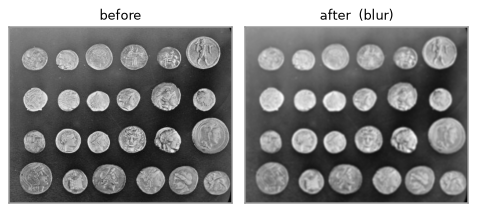

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import coins


g = coins().tolist()   # 303 x 384 흑백 이미지 = 2차원 리스트 (밝기 0~255)


def withinBoundary(height, width, i, j):
    return i >= 0 and i < height and j >= 0 and j < width


def blur(image):
    height = len(image)
    width = len(image[0])

    out = np.zeros((height, width))  # out = [[0.0] * width for _ in range(height)]

    for i in range(height):
        for j in range(width):
            # ADD ADDITIONAL CODE HERE!
            # 힌트: (i, j) 의 3x3 이웃을  for k in range(i - 1, i + 2),
            #       for w in range(j - 1, j + 2)  로 돌면서, withinBoundary(...) 인
            #       칸만 image[k][w] 를 더하고 개수를 센 뒤  out[i][j] = 합 / 개수
            out[i][j] = image[i][j]

    return out


plt.imshow(blur(g), cmap="gray")
plt.show()


## 2. 흰 배경에서 객체만 잘라내기

배경이 흰색(밝기 ≈ `255`)인 이미지에서, 객체(배경보다 어두운 픽셀)를 다
감싸는 가장 작은 직사각형만 남긴다. 이미지를 훑으면서 배경이 아닌
(`g[i][j] < thresh`) 픽셀을 만날 때마다 그 픽셀의 행/열 인덱스로
`min_i, max_i, min_j, max_j` 를 갱신하면, 그 네 값이 곧 그 직사각형이다.
(Problem 7 `maxZeroRect` 와 같은 "2차원 격자 속 직사각형" 문제.)

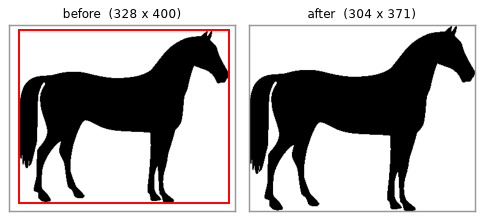

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import horse


g = np.where(horse(), 255, 0).tolist()   # 흰 배경(255) 위 말 실루엣(0), 2차원 리스트


def crop_object(g, thresh=250):
    H, W = len(g), len(g[0])

    min_i, max_i = H, -1
    min_j, max_j = W, -1

    for i in range(H):
        for j in range(W):
            if g[i][j] < thresh:                 # 배경(흰색)이 아닌 = 객체 픽셀
                # ADD ADDITIONAL CODE HERE!
                # min_i, max_i 는 i 로,  min_j, max_j 는 j 로 갱신
                pass

    # 찾은 직사각형만 잘라서 반환
    return [row[min_j:max_j + 1] for row in g[min_i:max_i + 1]]


crop = crop_object(g)
print(len(g), "x", len(g[0]), " ->  crop", len(crop), "x", len(crop[0]))

plt.imshow(crop, cmap="gray", vmin=0, vmax=255)
plt.show()


## 3. 주가 = 시간 × 종목 2차원 리스트

야후 파이낸스에서 세 종목(NVDA / 삼성전자 / SK하이닉스)의 종가를 받는다.
`pandas` 의 `DataFrame` 은 결국 `행(날짜) × 열(종목)` 표 — `df.values.tolist()`
하면 우리가 아는 2차원 리스트다.

통화·가격대가 달라서(₩5만 vs $15) 첫날 = 1 로 맞춰야 비교가 된다. 그다음
한 종목만 뽑아 20일 이동평균을 구한다 (시간축 이웃 평균 = 1번 blur 의 1차원 버전).

In [ ]:
!pip install -q yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

tickers = ["NVDA", "005930.KS", "000660.KS"]   # NVDA / 삼성전자 / SK하이닉스

try:
    df = yf.download(tickers, start="2023-01-01", end="2026-09-01",
                     auto_adjust=True, progress=False)["Close"].dropna()
    assert len(df) > 100
except Exception as e:
    print("다운로드 실패 -> 합성 데이터:", repr(e))
    n = 400
    df = pd.DataFrame(np.random.default_rng(0).uniform(50, 150, (n, len(tickers))),
                      columns=tickers,
                      index=pd.date_range("2023-01-02", periods=n, freq="B"))

print(df.shape)      # (날짜, 종목)
print(df.head())

# 가격대가 달라서 첫날 = 1.0 으로 맞춰 비교
(df / df.iloc[0]).plot()
plt.title("normalized (day 0 = 1.0)")
plt.show()


In [ ]:
price = df["NVDA"].tolist()   # NVDA 종가 한 열 -> 1차원 리스트


def moving_avg(col, w):
    out = np.zeros(len(col))  # out = [0.0] * len(col)

    for t in range(len(col)):
        lo = max(0, t - w + 1)
        pass  # ADD: col[lo..t] 의 평균을 out[t] 에

    return out


plt.plot(price, lw=.8)
plt.plot(moving_avg(price, 30))
plt.title("NVDA  price vs 30d moving avg")
plt.show()
